In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
SRMODELS  = CONFIGS['experiments']['sr']['optimizedeqs']
SPLIT     = 'test'
REGISTRY  = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
            for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpstd  = STATS['tp_std']
tpmean = STATS['tp_mean']
zmin  = -tpmean/tpstd

The normalized SR-BL equation discovered by PySR is:
$f = (\widetilde{B_L}+a)^3+b,\;\mathrm{where}\;\widetilde{B_L} = \frac{B_L-\mu_{B_L}}{s_{B_L}}$.

Substituting the standardization and collecting constants yields the physical form:
$\mathrm{P} = \max(\exp(\alpha(B_L - B_c)^3+\beta)-1,\,0)$,

with three interpretable constants:
1. $B_c$ = $\mu_{B_L} - a\,s_{B_L}$, the critical buoyancy threshold.
2. $\alpha$ = $s_y/(s_{B_L})^3$, the exponential sensitivity to departures from $B_c$.
3. $\beta$ = $s_y\,b$, the log-space offset controlling overall magnitude.

Precipitation onset (P > 0) occurs when $B_L > B_c - b^{1/3}\,s_{B_L}$.

In [4]:
constants = REGISTRY['sr_bl_eq']['constants']
a,b    = constants['a'],constants['b']
blmean = STATS['bl_mean']
blstd  = STATS['bl_std']

bc    = blmean-a*blstd
alpha = tpstd/blstd**3
beta  = tpstd*b
onset = bc-b**(1/3)*blstd

print(f'Physical constants:')
print(f'  Bc      = {bc:.4f} m/s²')
print(f'  alpha   = {alpha:.2f} (m/s²)⁻³')
print(f'  beta    = {beta:.4f}')
print(f'  P onset = {onset:.4f} m/s²')

Physical constants:
  Bc      = -0.0965 m/s²
  alpha   = 1659.98 (m/s²)⁻³
  beta    = 0.0740
  P onset = -0.1319 m/s²


In [5]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    bl = ds['bl'].transpose('time','lat','lon').values.ravel()
    tp = ds['tp'].transpose('time','lat','lon').values.ravel()

finite = np.isfinite(bl)&np.isfinite(tp)
bl = bl[finite]
tp = tp[finite]

print(f'Observed BL range: [{bl.min():.2f}, {bl.max():.2f}] m/s²')
print(f'Observed P range: [{tp.min():.2f}, {tp.max():.2f}] mm')

Observed BL range: [-0.52, 0.05] m/s²
Observed P range: [0.00, 107.02] mm


In [9]:
def predict_srbl_physical(bl):
    return np.maximum(np.expm1(alpha*(bl-bc)**3+beta),0.0)

def bin_1d(x,z,nbins=40,minsamples=50,plo=1,phi=99):
    mask = np.isfinite(x) & np.isfinite(z)
    x,z  = x[mask],z[mask]
    edges  = np.linspace(*np.percentile(x,[plo,phi]),nbins+1)
    xi     = np.clip(np.digitize(x,edges)-1,0,nbins-1)
    counts = np.bincount(xi,minlength=nbins)
    sums   = np.bincount(xi,weights=z,minlength=nbins)
    return 0.5*(edges[:-1]+edges[1:]),np.where(counts>=minsamples,sums/counts,np.nan),counts

blrange = np.linspace(np.percentile(bl,1),np.percentile(bl,99),300)
predtp  = predict_srbl_physical(blrange)
centers,tpmean,_ = bin_1d(bl,tp,nbins=40)

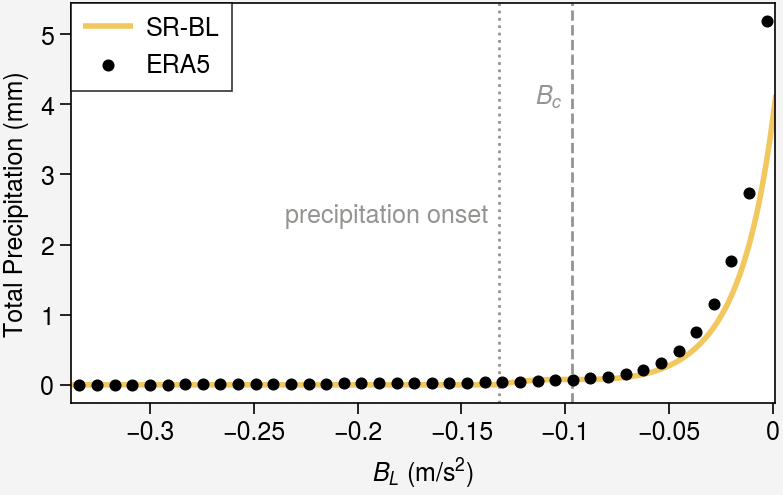

In [10]:
fig,ax = pplt.subplots(figwidth=4,refheight=2)
ax.format(grid=False,xlabel='$\\mathit{B_L}$ (m/s$^2$)',ylabel='Total Precipitation (mm)')
ax.plot(blrange,predtp,color=SRMODELS['sr_bl_eq']['color'],linewidth=2,label='SR-BL',zorder=2)
ax.scatter(centers,tpmean,color='k',markersize=14,label='ERA5',zorder=3)
ax.axvline(bc,color='gray',linewidth=1,linestyle='--',zorder=1)
ax.text(bc-0.005,0.8,'$\\mathit{B_c}$',ha='right',va='top',color='gray',transform=ax.get_xaxis_transform())
ax.axvline(onset,color='gray',linewidth=1,linestyle=':',zorder=1)
ax.text(onset-0.005,0.5,'precipitation onset',ha='right',va='top',color='gray',transform=ax.get_xaxis_transform())
ax.legend(loc='ul',ncols=1)
pplt.show()
fig.save('../figs/fig_3.jpg')